# Ajout des bibliothèques nécessaires

In [109]:
#importation des données
import os
import glob
from pathlib import Path
import json

# Manipulation des données
import pandas as pd
import numpy as np
import re
import string
import random

# Outils de Machine Learning (ici je vais utiliser Scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt




from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score


print("Toutes les bibliothèques sont chargées avec succès !")

Toutes les bibliothèques sont chargées avec succès !


## Segmentation des fichiers en paquets de 5 phrases

In [83]:
def segmenter_en_paquets(texte, taille_paquet=5):
    phrases = texte.splitlines()
    phrases = [p.strip() for p in phrases if p.strip()]

    paquets = []
    for i in range(0, len(phrases), taille_paquet):
        paquet = " ".join(phrases[i:i+taille_paquet])
        paquets.append(paquet)
    return paquets

chemin_dossier = "Z_vs_N"

liste_fichiers = sorted(glob.glob(os.path.join(chemin_dossier, "*.txt")))
print(f"Trouvé {len(liste_fichiers)} fichiers.")


random.seed(1)
random.shuffle(liste_fichiers)
liste_train = liste_fichiers[:40]
liste_test = liste_fichiers[40:]

print(f"Fichiers train : {len(liste_train)}")
print(f"Fichiers test  : {len(liste_test)}")


def construire_dataframe(liste_fichiers):

    donnees = []

    for chemin_fichier in liste_fichiers:
        nom_fichier = os.path.basename(chemin_fichier)
        if nom_fichier.endswith("clean.txt"):
            label = "Zola"
        else:
            label = "naturaliste"
        with open(chemin_fichier, "r", encoding="utf-8") as f:
            texte = f.read()
        blocs = segmenter_en_paquets(texte)
        for bloc in blocs:
            donnees.append({
                "texte": bloc,
                "label": label,
                "source": nom_fichier
            })
    return pd.DataFrame(donnees)


df_train = construire_dataframe(liste_train)
df_test = construire_dataframe(liste_test)

print("-"*30)
print("TRAIN")
print(df_train["label"].value_counts())

print("-"*30)
print("TEST")
print(df_test["label"].value_counts())

Trouvé 49 fichiers.
Fichiers train : 40
Fichiers test  : 9
------------------------------
TRAIN
label
Zola           22094
naturaliste    15301
Name: count, dtype: int64
------------------------------
TEST
label
Zola           5711
naturaliste    3037
Name: count, dtype: int64


In [84]:
print("Textes dans le train")
print(len(df_train))

sources_par_label = (
    df_train.groupby("label")["source"]
      .apply(lambda x: x.dropna().unique().tolist())
)

print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")
        
print("\n\n\nTextes dans le test)")
print(len(df_test))
        
sources_par_label = (
    df_test.groupby("label")["source"]
      .apply(lambda x: x.dropna().unique().tolist())
)

print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")

Textes dans le train
37395
------------------------------
Sources par label :

Zola :
  - 1873_3_Le_ventre_de_Paris._clean.txt
  - 1888_16_Le_reve._clean.txt
  - 1882_10_Pot-bouille._clean.txt
  - 1876_6_Son_Excellence_Eugene_Rougon._clean.txt
  - 1887_15_La_terre._clean.txt
  - 1884_12_La_joie_de_vivre._clean.txt
  - 1893_20_Le_docteur_Pascal._clean.txt
  - 1885_13_Germinal._clean.txt
  - 1883_11_Au_Bonheur_des_dames._clean.txt
  - 1874_4_La_conquete_de_Plassans._clean.txt
  - 1892_19_La_debacle._clean.txt
  - 1891_18_L_argent._clean.txt
  - 1871_1_La_fortune_des_Rougon._clean.txt
  - 1871_2_La_curee._clean.txt
  - 1877_7_L_assommoir._clean.txt
  - 1886_14_L_oeuvre._clean.txt

naturaliste :
  - malheur d'Henriette Gérard.txt
  - Amis de la nature.txt
  - En route.txt
  - rois_en_exil.txt
  - le_Nabab.txt
  - Germinie Lacerteux.txt
  - L'education_sentimentale.txt
  - Confessions de Sylvius.txt
  - soutien_de_famille.txt
  - Paule Méré.txt
  - Mont Oriol.txt
  - Barbier de Paris.txt
  

In [85]:
df_train.head()


,texte,label,source
0,"Au milieu du grand silence, et dans le désert ...",Zola,1873_3_Le_ventre_de_Paris._clean.txt
1,"Il marchait, dormant à demi, dodelinant des or...",Zola,1873_3_Le_ventre_de_Paris._clean.txt
2,"cria un des hommes, qui s’était mis à genoux s...",Zola,1873_3_Le_ventre_de_Paris._clean.txt
3,Eh! l’homme! dit-elle doucement. Mais les char...,Zola,1873_3_Le_ventre_de_Paris._clean.txt
4,"Il regardait Mme François d’un air effaré, san...",Zola,1873_3_Le_ventre_de_Paris._clean.txt


In [86]:
df_test.head()

,texte,label,source
0,I – Un article ?… Tu me demandes s’il y a un a...,naturaliste,Charles Demailly.txt
1,"– Après, après ? tu poses ta femme : une coméd...",naturaliste,Charles Demailly.txt
2,L’autre était un jeune homme de trente-quatre ...,naturaliste,Charles Demailly.txt
3,"Le second, tout entier à faire des appels au m...",naturaliste,Charles Demailly.txt
4,"Ces cinq hommes, qui avaient l’oreille à la bo...",naturaliste,Charles Demailly.txt


## Début d'entrainement du modèle Bayesien

In [99]:
chemin_json = Path("patronime.json")
with chemin_json.open("r", encoding="utf-8") as fichier:
    personnages_zola = json.load(fichier)

mots_supplementaires = [
    "buteau", "florent", 
    "faujas", "pauline", "coupeau", "plassans", 
    "nana", "pauline","chanteau","josserand", "miette", "lazare",
    "frédéric", "emma", "arnoux", "faustin", "germinie","duroy",
    "birotteau"]
    
    
stop_words_zola = set()

for personnage in personnages_zola:
    for champ in ("prenom", "nom"):
        valeur = personnage.get(champ, "")
        # Découpe les noms composés :
        # "Béraud du Châtel" devient "béraud", "du", "châtel"
        mots = re.findall(
            r"\b[\wÀ-ÿ'-]+\b",
            valeur.lower()
        )
        stop_words_zola.update(mots)

stop_words_zola.update(
    mot.lower() for mot in mots_supplementaires
)

# TfidfVectorizer accepte une liste
stop_words = sorted(stop_words_zola)

print("Nombre de stop words Zola :", len(stop_words))
print("Exemple :", stop_words[:20])

# Séparation des textes et des labels
X_train = df_train["texte"].fillna("")
y_train = df_train["label"]

X_test = df_test["texte"].fillna("")
y_test = df_test["label"]


# ============================================================
# TF-IDF COMMUN AUX TROIS MODÈLES
# ============================================================


vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    stop_words=stop_words
)

# Le vocabulaire et les poids IDF sont appris uniquement sur le train
X_train_tfidf = vectorizer.fit_transform(X_train)

# Le test est transformé avec exactement le même vocabulaire
X_test_tfidf = vectorizer.transform(X_test)

print("Dimensions du train :", X_train_tfidf.shape)
print("Dimensions du test  :", X_test_tfidf.shape)

Nombre de stop words Zola : 343
Exemple : ['adeline', 'adélaïde', 'agathe', 'alexandre', 'alexandre-honoré', 'alfred', 'alice', 'alzire', 'ambroise', 'andrée', 'anglars', 'angèle', 'angélique', 'anna', 'antoine', 'antoinette', 'antonin', 'aristide', 'arnoux', 'attilio']
Dimensions du train : (37395, 10000)
Dimensions du test  : (8748, 10000)


              precision    recall  f1-score   support

        Zola       0.94      0.95      0.95      5711
 naturaliste       0.91      0.88      0.90      3037

    accuracy                           0.93      8748
   macro avg       0.92      0.92      0.92      8748
weighted avg       0.93      0.93      0.93      8748

[[5444  267]
 [ 351 2686]]


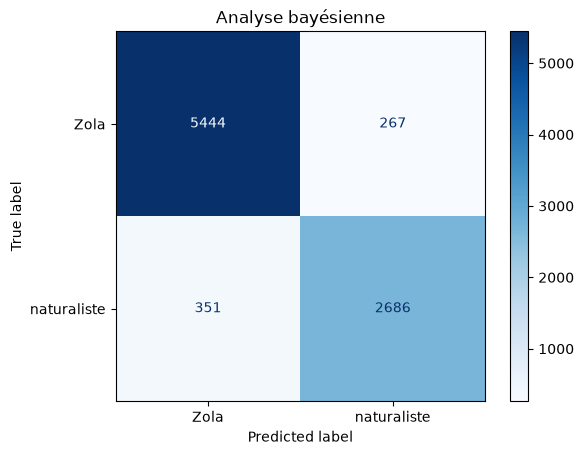

In [88]:
modele_bayes = MultinomialNB(alpha=1.0)

modele_bayes.fit(X_train_tfidf, y_train)


predictions = modele_bayes.predict(X_test_tfidf)

print(classification_report(y_test, predictions))

cm_bayesien = confusion_matrix(y_test, predictions)
print(cm_bayesien)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bayesien,
    display_labels=modele_bayes.classes_
).plot(cmap="Blues")

plt.title("Analyse bayésienne")
plt.show()

In [100]:
vectorizer = vectorizer
classifieur = modele_bayes

mots = vectorizer.get_feature_names_out()
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Différence des log-probabilités entre les deux classes
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats_mots = pd.DataFrame({
    "mot": mots,
    f"score_{classes[0]}": score_discriminant
})

# Mots les plus caractéristiques de la première classe
mots_classe_0 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=False
).head(30)

# Mots les plus caractéristiques de la deuxième classe
mots_classe_1 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=True
).head(30)

print(f"\nMots les plus caractéristiques de {classes[0]} :")
for _, ligne in mots_classe_0.iterrows():
    print(f"{ligne['mot']:<25} {ligne[f'score_{classes[0]}']:.3f}")

print(f"\nMots les plus caractéristiques de {classes[1]} :")
for _, ligne in mots_classe_1.iterrows():
    print(f"{ligne['mot']:<25} {-ligne[f'score_{classes[0]}']:.3f}")

Ordre des classes : ['Zola' 'naturaliste']

Mots les plus caractéristiques de Zola :
lorsqu                    3.260
lavoir                    3.015
mai                       2.992
maréchal                  2.959
près lui                  2.951
jésus christ              2.946
très                      2.941
chaudes                   2.917
embrasse                  2.896
debout                    2.891
facile                    2.873
véronique                 2.873
camarades                 2.869
debout devant             2.834
gelée                     2.800
monté                     2.785
rayons                    2.765
goutte                    2.762
police                    2.757
comtesse                  2.746
aurions                   2.689
sein                      2.671
bouleversé                2.626
je voulais                2.625
glaces                    2.624
huissier                  2.617
corbeilles                2.615
borne                     2.606
joliment           

In [101]:
for mot in ["buteau", "florent", "faujas", "pauline", "coupeau"]:
    nb = df_test["texte"].str.contains(mot, case=False).sum()
    print(mot, nb)

buteau 2
florent 1
faujas 0
pauline 82
coupeau 0


In [102]:
# Utilisation du TF-IDF commun
vectorizer = vectorizer
classifieur = modele_bayes

# Vocabulaire appris sur le train
termes = vectorizer.get_feature_names_out()

# Ordre réel des classes
classes = classifieur.classes_

print("Ordre des classes :", classes)

# X_test_tfidf existe déjà et est commun aux trois modèles

# Transformation du jeu de test avec le vectorizer déjà entraîné
X_test_tfidf = vectorizer.transform(df_test["texte"])

# Nombre d'extraits du test contenant chaque terme
presence_test = np.asarray((X_test_tfidf > 0).sum(axis=0)).ravel()

# Somme des poids TF-IDF de chaque terme dans le test
poids_tfidf_test = np.asarray(X_test_tfidf.sum(axis=0)).ravel()

# Score discriminant appris par Naive Bayes
# score positif : classe 0
# score négatif : classe 1
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats = pd.DataFrame({
    "terme": termes,
    "score_discriminant": score_discriminant,
    "nb_extraits_test": presence_test,
    "poids_tfidf_test": poids_tfidf_test
})

# On conserve uniquement les termes présents dans le test
resultats_test = resultats[
    resultats["nb_extraits_test"] > 0
].copy()

print(f"\nNombre de termes du vocabulaire présents dans le test : "
      f"{len(resultats_test)}")

Ordre des classes : ['Zola' 'naturaliste']

Nombre de termes du vocabulaire présents dans le test : 9747


In [103]:
n = 30

termes_classe_0 = (
    resultats_test
    .sort_values("score_discriminant", ascending=False)
    .head(n)
)

termes_classe_1 = (
    resultats_test
    .sort_values("score_discriminant", ascending=True)
    .head(n)
)

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[0]} :")

for _, ligne in termes_classe_0.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[1]} :")

for _, ligne in termes_classe_1.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )


Termes présents dans le test les plus caractéristiques de Zola :
lorsqu                    score=3.260  extraits=399
lavoir                    score=3.015  extraits=16
mai                       score=2.992  extraits=16
maréchal                  score=2.959  extraits=9
près lui                  score=2.951  extraits=34
jésus christ              score=2.946  extraits=3
très                      score=2.941  extraits=1085
chaudes                   score=2.917  extraits=18
embrasse                  score=2.896  extraits=33
debout                    score=2.891  extraits=272
facile                    score=2.873  extraits=41
camarades                 score=2.869  extraits=59
debout devant             score=2.834  extraits=30
gelée                     score=2.800  extraits=11
monté                     score=2.785  extraits=52
rayons                    score=2.765  extraits=39
goutte                    score=2.762  extraits=39
police                    score=2.757  extraits=40
comtesse      

In [104]:
resultats_test["contribution_test"] = (
    resultats_test["score_discriminant"]
    * resultats_test["poids_tfidf_test"]
)

In [105]:
contributions_zola = (
    resultats_test
    .sort_values("contribution_test", ascending=False)
    .head(30)
)

contributions_naturalistes = (
    resultats_test
    .sort_values("contribution_test", ascending=True)
    .head(30)
)

print(f"\nTermes ayant le plus contribué aux prédictions {classes[0]} :")

for _, ligne in contributions_zola.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"contribution={ligne['contribution_test']:.3f}  "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes ayant le plus contribué aux prédictions {classes[1]} :")

for _, ligne in contributions_naturalistes.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"contribution={-ligne['contribution_test']:.3f}  "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )


Termes ayant le plus contribué aux prédictions Zola :
il                        contribution=289.057  score=0.673  extraits=6013
elle                      contribution=286.664  score=0.594  extraits=4834
je                        contribution=284.179  score=1.058  extraits=3027
en                        contribution=283.900  score=1.052  extraits=5275
très                      contribution=238.553  score=2.941  extraits=1085
que                       contribution=160.587  score=0.595  extraits=5016
ah                        contribution=144.984  score=1.831  extraits=867
était                     contribution=144.117  score=0.738  extraits=3571
ce                        contribution=140.396  score=0.667  extraits=3864
par                       contribution=138.547  score=0.929  extraits=2682
qu il                     contribution=130.390  score=1.390  extraits=1388
donc                      contribution=118.824  score=1.293  extraits=1086
lorsqu                    contribution=117.197

## 2. Régression logistique

=== Régression logistique ===
              precision    recall  f1-score   support

        Zola      0.969     0.961     0.965      5711
 naturaliste      0.928     0.943     0.935      3037

    accuracy                          0.955      8748
   macro avg      0.949     0.952     0.950      8748
weighted avg      0.955     0.955     0.955      8748

Matrice de confusion :
[[5489  222]
 [ 173 2864]]


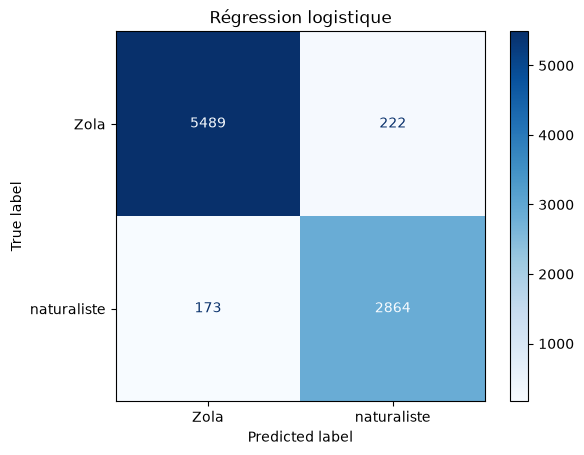

In [106]:
# Entraînement direct, sans Pipeline
modele_logistique = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

modele_logistique.fit(X_train_tfidf, y_train)

predictions_logistiques = modele_logistique.predict(X_test_tfidf)

print("=== Régression logistique ===")
print(classification_report(y_test, predictions_logistiques, digits=3))

cm_logistique = confusion_matrix(y_test, predictions_logistiques)
print("Matrice de confusion :")
print(cm_logistique)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistique,
    display_labels=modele_logistique.classes_
).plot(cmap="Blues")

plt.title("Régression logistique")
plt.show()

In [107]:
# Termes les plus discriminants de la régression logistique
termes_logistiques = vectorizer.get_feature_names_out()
classes_logistiques = modele_logistique.classes_

print("Ordre des classes :", classes_logistiques)

# En classification binaire :
# - coefficient positif  -> classe classes_[1]
# - coefficient négatif  -> classe classes_[0]
coefficients = modele_logistique.coef_[0]

importance_logistique = pd.DataFrame({
    "terme": termes_logistiques,
    "coefficient": coefficients
})

n = 30

termes_classe_0 = (
    importance_logistique
    .sort_values("coefficient", ascending=True)
    .head(n))

termes_classe_1 = (
    importance_logistique
    .sort_values("coefficient", ascending=False)
    .head(n))

print(f"\nTermes les plus associés à {classes_logistiques[0]} :")
for _, ligne in termes_classe_0.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

print(f"\nTermes les plus associés à {classes_logistiques[1]} :")
for _, ligne in termes_classe_1.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")


Ordre des classes : ['Zola' 'naturaliste']

Termes les plus associés à Zola :
lorsque                        -5.8087
abbé                           -5.4556
qu                             -5.1573
lorsqu                         -4.8220
ça                             -4.5888
était                          -4.4798
ai                             -4.3688
empereur                       -3.8951
tout un                        -3.3983
hein                           -3.3189
simplement                     -3.0973
avait                          -3.0823
ce pas                         -3.0614
air                            -3.0011
dut                            -2.9047
berthe                         -2.8830
oncle                          -2.8744
ce fut                         -2.8740
un coup                        -2.8672
très                           -2.8502
avoir                          -2.8375
être                           -2.7985
tandis que                     -2.7936
nouveau                  

## 3. Analyse discriminante linéaire

L'analyse discriminante linéaire ne travaille pas directement sur une matrice TF-IDF creuse comportant plusieurs milliers de colonnes. On réduit donc d'abord la dimension avec `TruncatedSVD`, puis on standardise les composantes avant d'entraîner la LDA.

=== Analyse discriminante linéaire ===
Nombre de composantes SVD : 100
Variance expliquée cumulée par la SVD : 0.140
              precision    recall  f1-score   support

        Zola      0.931     0.966     0.948      5711
 naturaliste      0.931     0.865     0.897      3037

    accuracy                          0.931      8748
   macro avg      0.931     0.916     0.922      8748
weighted avg      0.931     0.931     0.930      8748

Matrice de confusion :
[[5515  196]
 [ 409 2628]]


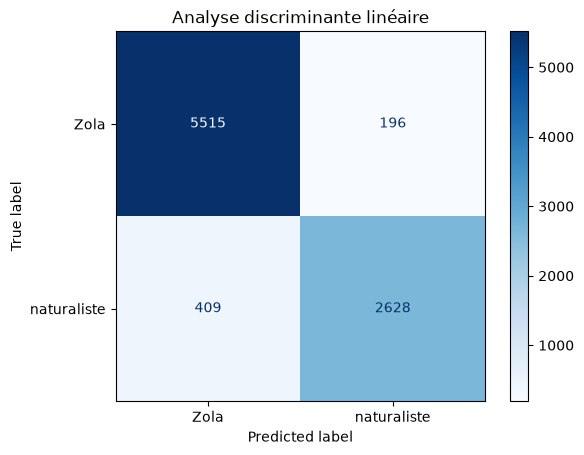

In [108]:
# Nombre de composantes compatible avec la taille réelle des données
n_composantes = min(
    100,
    X_train_tfidf.shape[0] - 1,
    X_train_tfidf.shape[1] - 1)

# Réduction de dimension
svd = TruncatedSVD(
    n_components=n_composantes,
    random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# Standardisation
scaler_lda = StandardScaler()
X_train_lda = scaler_lda.fit_transform(X_train_svd)
X_test_lda = scaler_lda.transform(X_test_svd)

# Analyse discriminante linéaire
modele_lda = LinearDiscriminantAnalysis(solver="svd")
modele_lda.fit(X_train_lda, y_train)

predictions_lda = modele_lda.predict(X_test_lda)

print("=== Analyse discriminante linéaire ===")
print(f"Nombre de composantes SVD : {n_composantes}")
print(
    "Variance expliquée cumulée par la SVD : "
    f"{svd.explained_variance_ratio_.sum():.3f}"
)
print(classification_report(y_test, predictions_lda, digits=3))

cm_lda = confusion_matrix(y_test, predictions_lda)
print("Matrice de confusion :")
print(cm_lda)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lda,
    display_labels=modele_lda.classes_
).plot(cmap="Blues")

plt.title("Analyse discriminante linéaire")
plt.show()


# Comparaison des modèles

In [98]:
comparaison_modeles = pd.DataFrame({
    "modèle": [
        "Analyse bayésienne",
        "Régression logistique",
        "Analyse discriminante linéaire"
    ],

    "accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, predictions_logistiques),
        accuracy_score(y_test, predictions_lda)
    ],

    "f1_macro": [
        f1_score(y_test, predictions, average="macro"),
        f1_score(y_test, predictions_logistiques, average="macro"),
        f1_score(y_test, predictions_lda, average="macro")
    ]
})

comparaison_modeles.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)

,modèle,accuracy,f1_macro
0,Régression logistique,0.955533,0.951044
1,Analyse bayésienne,0.929355,0.921558
2,Analyse discriminante linéaire,0.927069,0.918355
